<img src="./assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Lab: Simple Linear Regression with Sacramento Real Estate Data

---

In this lab you will hone your exploratory data analysis (EDA) skills and practice constructing linear regressions on a data set of Sacramento real estate sales.  The data set contains information on qualities of the property, location of the property, and time of sale.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

### 1. Read in the Sacramento housing data set.

The file is stored in the `data` subfolder.

In [2]:
housing = pd.read_csv('./data/sacramento_real_estate_transactions.csv')

### 2. Conduct exploratory data analysis on this data set. 

If you discover any issues with the data, fix them to the best of your ability. Report any notable findings.

__Note:__
- Assign the correct data type to each column.
- Look for missing values and determine how to handle them. Keep in mind that most machine learning models cannot process null values.
- Check the value ranges for numerical and categorical columns to identify any anomalies.
- Examine the distribution of values and investigate potential outliers.

In [3]:
housing.dtypes

street        object
city          object
zip            int64
state         object
beds           int64
baths          int64
sq__ft         int64
type          object
sale_date     object
price          int64
latitude     float64
longitude    float64
dtype: object

In [4]:
housing['sale_date'] = pd.to_datetime(housing['sale_date'])
housing['zip'] = housing['zip'].astype(str)
housing.head()

C:\Users\dell\AppData\Local\Temp\ipykernel_11928\3382835146.py:1: FutureWarning: Parsed string "Wed May 21 00:00:00 EDT 2008" included an un-recognized timezone "EDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  housing['sale_date'] = pd.to_datetime(housing['sale_date'])


,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768


In [5]:
housing.isnull().sum()

street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [6]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   street     985 non-null    object        
 1   city       985 non-null    object        
 2   zip        985 non-null    object        
 3   state      985 non-null    object        
 4   beds       985 non-null    int64         
 5   baths      985 non-null    int64         
 6   sq__ft     985 non-null    int64         
 7   type       985 non-null    object        
 8   sale_date  985 non-null    datetime64[ns]
 9   price      985 non-null    int64         
 10  latitude   985 non-null    float64       
 11  longitude  985 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(5)
memory usage: 92.5+ KB


In [7]:
print(housing.duplicated().sum())
housing = housing.drop_duplicates()

3


In [8]:
housing.describe()

,beds,baths,sq__ft,sale_date,price,latitude,longitude
count,982.000000,982.000000,982.000000,982,982.000000,982.000000,982.000000
mean,2.914460,1.779022,1314.776986,2008-05-18 05:09:24.562118144,234185.358452,38.444300,-121.192904
min,0.000000,0.000000,-984.000000,2008-05-15 00:00:00,-210944.000000,-121.503471,-121.551704
25%,2.000000,1.000000,953.000000,2008-05-16 00:00:00,145000.000000,38.482337,-121.446104
50%,3.000000,2.000000,1304.500000,2008-05-19 00:00:00,215000.000000,38.625611,-121.376010
75%,4.000000,2.000000,1719.500000,2008-05-20 00:00:00,300000.000000,38.694512,-121.295114
max,8.000000,5.000000,5822.000000,2008-05-21 00:00:00,884790.000000,39.020808,38.668433
std,1.305838,0.894568,856.266836,NaN,138992.002773,5.111407,5.108454


In [9]:
print(housing[['latitude', 'longitude']].describe())

         latitude   longitude
count  982.000000  982.000000
mean    38.444300 -121.192904
std      5.111407    5.108454
min   -121.503471 -121.551704
25%     38.482337 -121.446104
50%     38.625611 -121.376010
75%     38.694512 -121.295114
max     39.020808   38.668433


In [10]:
housing.isnull().sum()

street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [11]:
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768


In [12]:
housing.nunique()

street       981
city          39
zip           68
state          2
beds           8
baths          6
sq__ft       604
type           4
sale_date      5
price        605
latitude     969
longitude    967
dtype: int64

In [13]:
print(housing['state'].unique())

['CA' 'AC']


In [14]:
print(housing['beds'].unique())

[2 3 1 4 0 5 8 6]


In [15]:
housing = housing[housing['beds'] > 0]

In [16]:
housing = housing[housing['baths'] > 0]

In [17]:
print(housing['sq__ft'].describe())

housing = housing[housing['sq__ft'] > 0]

print(housing['price'].describe())
print(housing[housing['price'] < 20000][['street', 'city', 'beds', 'baths', 'sq__ft', 'price']])

count     875.000000
mean     1475.555429
std       765.144139
min      -984.000000
25%      1093.500000
50%      1375.000000
75%      1800.500000
max      5822.000000
Name: sq__ft, dtype: float64
count       811.000000
mean     229746.900123
std      119891.141884
min        2000.000000
25%      148750.000000
50%      208000.000000
75%      285000.000000
max      884790.000000
Name: price, dtype: float64
             street         city  beds  baths  sq__ft  price
866  14151 INDIO DR  SLOUGHHOUSE     3      4    5822   2000


In [18]:
print(housing['city'].unique())

['SACRAMENTO' 'RANCHO CORDOVA' 'RIO LINDA' 'CITRUS HEIGHTS'
 'NORTH HIGHLANDS' 'ANTELOPE' 'ELK GROVE' 'ELVERTA' 'GALT' 'CARMICHAEL'
 'ORANGEVALE' 'FOLSOM' 'MATHER' 'POLLOCK PINES' 'GOLD RIVER'
 'RANCHO MURIETA' 'WILTON' 'GREENWOOD' 'FAIR OAKS' 'PLACERVILLE'
 'MEADOW VISTA' 'ROSEVILLE' 'LINCOLN' 'CAMERON PARK' 'ROCKLIN' 'LOOMIS'
 'AUBURN' 'EL DORADO HILLS' 'EL DORADO' 'PENRYN' 'GRANITE BAY'
 'DIAMOND SPRINGS' 'COOL' 'WALNUT GROVE' 'SLOUGHHOUSE' 'WEST SACRAMENTO']


In [19]:
print(housing['type'].unique()) 

['Residential' 'Condo' 'Multi-Family']


In [20]:
#print(housing['street'].unique())

In [21]:
housing['state'] = housing['state'].replace('AC', 'CA')
print(housing['state'].unique())

['CA']


In [22]:
print(housing['type'].unique())
housing['type'] = housing['type'].replace('Unkown', 'Unknown')
housing['type'] = housing['type'].astype('category')
print(housing['type'].value_counts())

['Residential' 'Condo' 'Multi-Family']
type
Residential     757
Condo            41
Multi-Family     13
Name: count, dtype: int64


In [23]:
housing = housing[housing['price'] >0]
housing

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768
...,...,...,...,...,...,...,...,...,...,...,...,...
980,9169 GARLINGTON CT,SACRAMENTO,95829,CA,4,3,2280,Residential,2008-05-15,232425,38.457679,-121.359620
981,6932 RUSKUT WAY,SACRAMENTO,95823,CA,3,2,1477,Residential,2008-05-15,234000,38.499893,-121.458890
982,7933 DAFFODIL WAY,CITRUS HEIGHTS,95610,CA,3,2,1216,Residential,2008-05-15,235000,38.708824,-121.256803
983,8304 RED FOX WAY,ELK GROVE,95758,CA,4,2,1685,Residential,2008-05-15,235301,38.417000,-121.397424


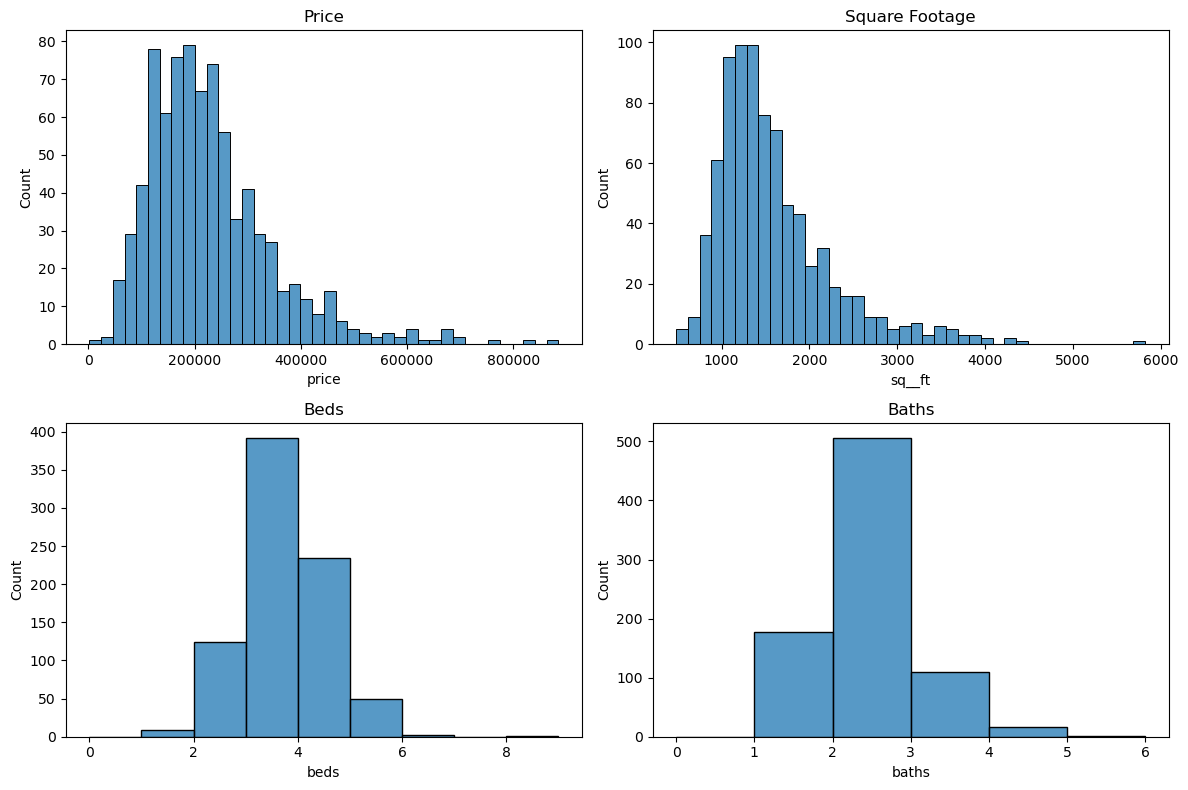

In [24]:
# quick look at the distributions / potential outliers for our key numeric columns
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(housing['price'], bins=40, ax=axes[0,0]).set_title('Price')
sns.histplot(housing['sq__ft'], bins=40, ax=axes[0,1]).set_title('Square Footage')
sns.histplot(housing['beds'], bins=range(0,10), ax=axes[1,0]).set_title('Beds')
sns.histplot(housing['baths'], bins=range(0,7), ax=axes[1,1]).set_title('Baths')
plt.tight_layout()
plt.show()

In [25]:
# Data Cleaning: Filter out extreme outliers in square footage
# The histogram showed a detached data point (> 5500) that distorts the distribution
housing = housing[housing['sq__ft'] < 5500]
housing.shape

(810, 12)

In [26]:
housing = housing.reset_index(drop=True)

In [27]:
housing.shape

(810, 12)

In [28]:
housing.describe()

,beds,baths,sq__ft,sale_date,price,latitude,longitude
count,810.000000,810.000000,810.000000,810,810.000000,810.000000,810.000000
mean,3.248148,1.960494,1587.991358,2008-05-18 05:02:13.333333248,230028.069136,38.576913,-121.378851
min,1.000000,1.000000,484.000000,2008-05-15 00:00:00,30000.000000,38.241514,-121.550527
25%,3.000000,2.000000,1144.500000,2008-05-16 00:00:00,148812.500000,38.473785,-121.451501
50%,3.000000,2.000000,1419.500000,2008-05-19 00:00:00,208000.000000,38.591720,-121.405456
75%,4.000000,2.000000,1851.000000,2008-05-20 00:00:00,285000.000000,38.674704,-121.326348
max,8.000000,5.000000,4400.000000,2008-05-21 00:00:00,884790.000000,39.008159,-120.597599
std,0.848996,0.665906,647.645647,NaN,119697.367127,0.126448,0.119571


When you've finished cleaning or have made a good deal of progress cleaning, it's always a good idea to save your work. Use the pandas `to_csv` method to export your cleaned dataset.

```python
# example -- your dataframe name may be different
dataframe.to_csv('./datasets/sacramento_cleaned_dataframe.csv', index=False)

```

In [29]:
housing.to_csv('./data/sacramento_cleaned1_dataframe.csv', index=False)

### 3. Our goal will be to predict price. List variables that you think qualify as predictors of price in an SLR model.

For each of the variables you believe should be considered, generate a plot showing the relationship between the independent and dependent variables.

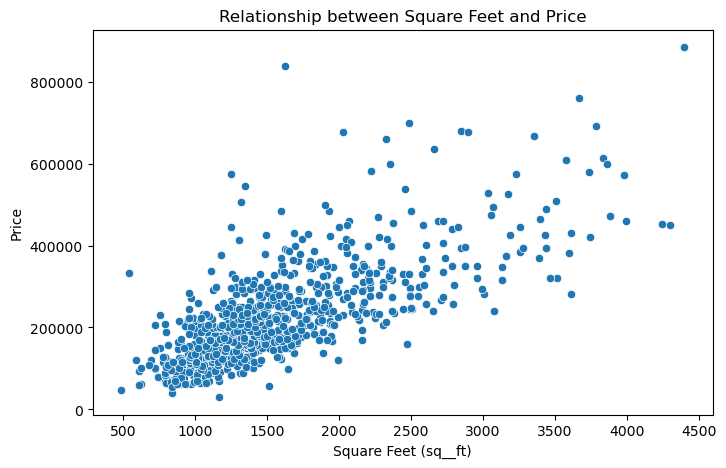

In [30]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=housing, x='sq__ft', y='price')
plt.title('Relationship between Square Feet and Price')
plt.xlabel('Square Feet (sq__ft)')
plt.ylabel('Price')
plt.show()

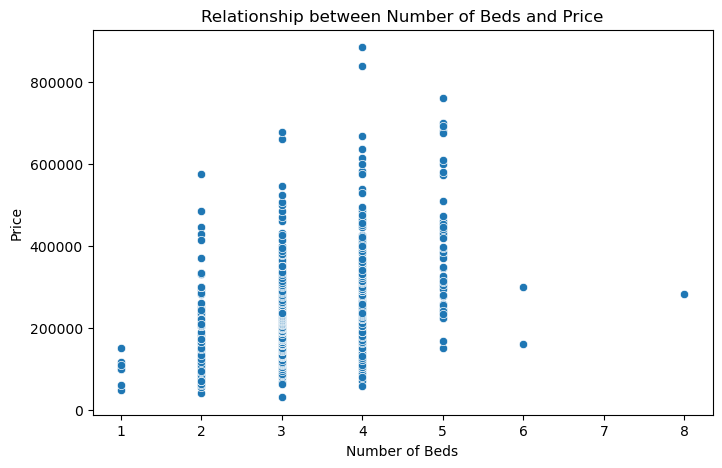

In [31]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=housing, x='beds', y='price') # الـ Boxplot أو الـ Scatter ممتاز للمتغيرات المتقطعة (Discrete)
plt.title('Relationship between Number of Beds and Price')
plt.xlabel('Number of Beds')
plt.ylabel('Price')
plt.show()

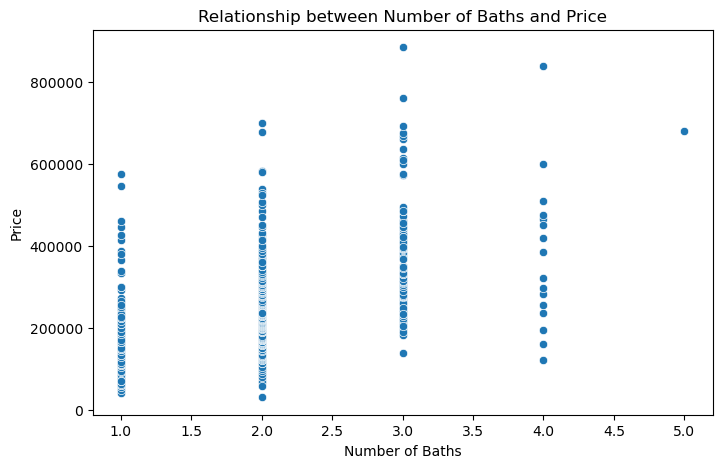

In [32]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=housing, x='baths', y='price')
plt.title('Relationship between Number of Baths and Price')
plt.xlabel('Number of Baths')
plt.ylabel('Price')
plt.show()

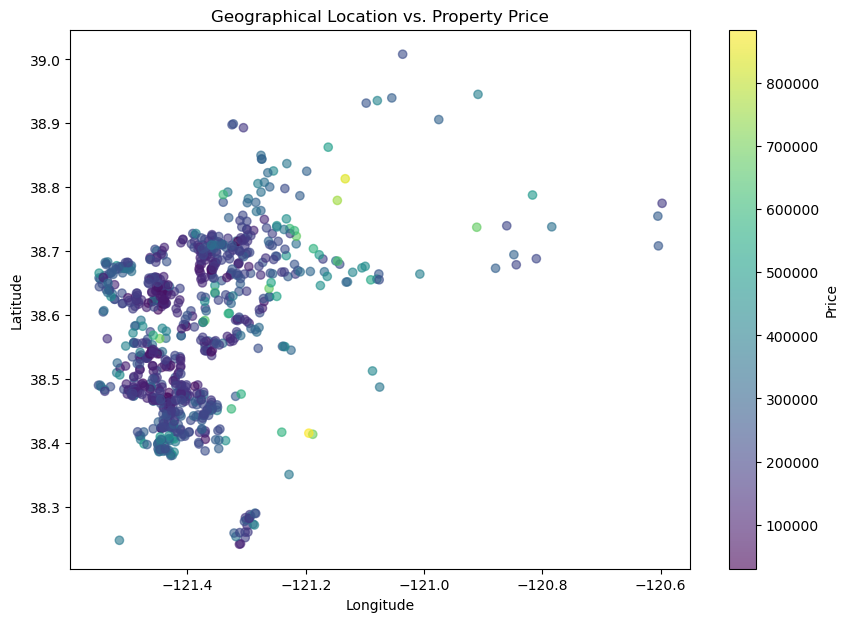

In [33]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(data=housing, x='longitude', y='latitude', c='price', cmap='viridis', alpha=0.6)

plt.colorbar(scatter, label='Price')
plt.title('Geographical Location vs. Property Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### 4. Which variable would be the best predictor of Y in an SLR model? Why?

In [34]:
corr_with_price = housing[['beds', 'baths', 'sq__ft', 'latitude', 'longitude', 'price']].corr()['price'].sort_values(ascending=False)
print(corr_with_price)

# Answer: sqft (area) is the best single variable to predict the price, because it has the highest correlation with price (around 0.73),
# which is clearly higher than the other variables, and the relationship in the chart above also looks reasonably linear.

price        1.000000
sq__ft       0.728268
baths        0.512347
beds         0.443219
longitude    0.284505
latitude     0.057508
Name: price, dtype: float64


### 5. Write a function that will take in two lists, `x` and `y`, and return the intercept and slope coefficients that minimize SSE. 

`y` is the target variable, and `x` is the predictor variable.

**Don't use `scikit-learn` for this**. Instead, use `numpy`.

The slope and intercept of simple linear regression can be calculated by using certain summary statistics. In particular, we'll need to know:

- $\bar{x}$, the mean of `x`
- $\bar{y}$, the mean of `y`
- $s_{x}$, the standard deviation of `x`
- $s_{y}$, the standard deviation of `y`
- $r_{xy}$, the correlation of `x` and `y`

Given these summary statistics, the **coefficient on `X`** (or the slope) can be given by $\beta_{1} = r_{xy} * \frac{s_{y}}{s_{x}}$. The **intercept of the model** can be given by $\beta_{0} = \bar{y} - \beta_{1}\bar{x}$.

Your function should take in `x` and `y`, then use the above summary statistics to calculate the slope and intercept.

- **Test your function on price and the variable you determined was the best predictor in Problem 4.**
- **Report the slope and intercept.**

In [35]:
def simple_linear_regression(x, y):
    
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    x_bar, y_bar = x.mean(), y.mean()
    s_x, s_y = x.std(ddof=1), y.std(ddof=1)
    r_xy = np.corrcoef(x, y)[0, 1]

    slope = r_xy * (s_y / s_x)
    intercept = y_bar - slope * x_bar
    return intercept, slope

intercept, slope = simple_linear_regression(housing['sq__ft'], housing['price'])
print(f"Intercept : {intercept:,.2f}")
print(f"Slope : {slope:,.2f}")

Intercept : 16,287.64
Slope : 134.60


In [36]:
# sanity check against sklearn -- these numbers should match (up to floating point rounding)
lr_check = LinearRegression()
lr_check.fit(housing[['sq__ft']], housing['price'])
print("sklearn intercept:", lr_check.intercept_)
print("sklearn slope:    ", lr_check.coef_[0])

sklearn intercept: 16287.636342221347
sklearn slope:     134.59798235895545


### 6. Interpret the intercept and the slope.

- **Slope (≈ 134.6):** For every extra square foot of house space, the price is expected to go up by about $134.5, assuming all other factors stay the same (which makes sense in the context of SLR since it's the only variable in the model).
- **Intercept (≈ 16,287.64):** This is the theoretically expected price for a house with zero square feet. It doesn’t really make practical sense (there’s no house with zero space), but it’s mathematically necessary to position the regression line.

### 7. Give an example of how this model could be used for prediction and how it could be used for inference. 

**Be sure to make it clear which example is associated with prediction and which is associated with inference.**

**Example of Usage in Prediction:**
If we know that a new house for sale has an area of 1,500 square feet, we can use the model to calculate the expected price:
`price ≈ 16,540 + 134.5 × 1500 ≈ $218,290`. Here the focus is just on getting an accurate estimate of the price.

**Example of Usage in Inference:**
The slope value (134.5) itself can be used to answer the question: "How much is the expected increase in the house price in the Sacramento market for each additional square foot?" Here, the focus is on understanding and interpreting the relationship between the variables, not just generating a prediction for a specific property.

### 8: [Bonus] Using the model you came up with in Problem 5, calculate and plot the residuals.

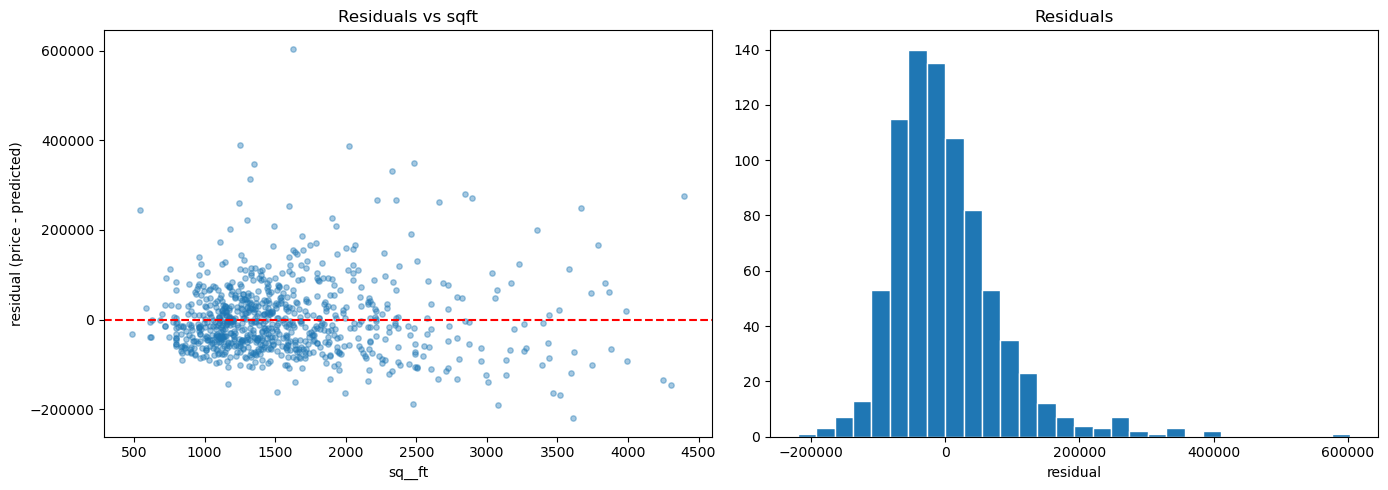

In [37]:
predicted_price = intercept + slope * housing['sq__ft']
residuals = housing['price'] - predicted_price

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(housing['sq__ft'], residuals, alpha=0.4, s=15)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('sq__ft')
axes[0].set_ylabel('residual (price - predicted)')
axes[0].set_title('Residuals vs sqft')

axes[1].hist(residuals, bins=30, edgecolor='white')
axes[1].set_title('Residuals')
axes[1].set_xlabel('residual')

plt.tight_layout()
plt.show()

---

## Dummy Variables

It is important to be cautious with categorical variables, which represent distict groups or categories, when building a regression. If put in a regression "as-is," categorical variables represented as integers will be treated like *continuous* variables.

That is to say, instead of group "3" having a different effect on the estimation than group "1" it will estimate literally 3 times more than group 1. 

For example, if occupation category "1" represents "analyst" and occupation category "3" represents "barista", and our target variable is salary, if we leave this as a column of integers then barista will always have `beta*3` the effect of analyst.

This will almost certainly force the beta coefficient to be something strange and incorrect. Instead, we can re-represent the categories as multiple "dummy coded" columns.



#### A Word of Caution When Creating Dummies

Let's touch on precautions we should take when dummy coding.

**If you convert a qualitative variable to dummy variables, you want to turn a variable with N categories into N-1 variables.**

> **Scenario 1:** Suppose we're working with the variable "sex" or "gender" with values "M" and "F". 

You should include in your model only one variable for "sex = F" which takes on 1 if sex is female and 0 if sex is not female! Rather than saying "a one unit change in X," the coefficient associated with "sex = F" is interpreted as the average change in Y when sex = F relative to when sex = M.

| Female | Male | 
|-------|------|
| 0 | 1 | 
| 1 | 0 |
| 0 | 1 |
| 1 | 0 |
| 1 | 0 |
_As we can see a 1 in the female column indicates a 0 in the male column. And so, we have two columns stating the same information in different ways._

> Scenario 2: Suppose we're modeling revenue at a bar for each of the days of the week. We have a column with strings identifying which day of the week this observation occured in.

We might include six of the days as their own variables: "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday". **But not all 7 days.**  

|Monday | Tuesday | Wednesday | Thursday | Friday | Saturday | 
|-------|---------|-----------|----------|--------|----------|
| 1     | 0       |0          |      0   |0       | 0        | 
| 0     | 1       |0          |      0   |0       | 0        | 
| 0     | 0       |1          |      0   |0       | 0        | 
| 0     | 0       |0          |      1   |0       | 0        | 
| 0     | 0       |0          |      0   |1       | 0        | 
| 0     | 0       |0          |      0   |0       | 1        | 
| 0     | 0       |0          |      0   |0       | 0        | 

_As humans we can infer from the last row that if its is not Monday, Tuesday, Wednesday, Thursday, Friday or Saturday, it must be Sunday. Models work the same way._

The coefficient for Monday is then interpreted as the average change in revenue when "day = Monday" relative to "day = Sunday." The coefficient for Tuesday is interpreted as the average change in revenue when "day = Tuesday" relative to "day = Sunday" and so on.

The category you leave out, which the other columns are *relative to*, is often referred to as the **reference category**.

### 9. Use the `pd.get_dummies` function to convert the `type` column into dummy-coded variables.

In [38]:
type_dummies = pd.get_dummies(housing['type'], prefix='type', drop_first=True)
type_dummies.head()

,type_Multi-Family,type_Residential
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True


### 10. Check the dummy columns you've created. Do they all make sense?

Use `.head()` on the new dataframe you've created. Depending on how you cleaned the data earlier in this notebook, there may be a dummy column that needs to be removed. Check that all the columns you've created make sense, and if any of the columns seem to be errors, drop them. If there don't appear to be any errors, then move on to the next step!

In [39]:
housing_dummies = pd.concat([housing, type_dummies], axis=1)
housing_dummies.head()


,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude,type_Multi-Family,type_Residential
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879,False,True
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028,False,True
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839,False,True
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146,False,True
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768,False,True


### 11. Build what you think may be the best MLR model predicting `price`. 

Choose at least three variables, and build a model that uses them to predict price. At least one of the variables you choose should be a dummy-coded variable. (This can be one we created before or a new one.) 

You may need to load in the scikit-learn API:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

In [40]:
features = ['sq__ft', 'beds', 'baths'] + list(type_dummies.columns)
X = housing_dummies[features]
y = housing_dummies['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print('Features:', features)
print('Coefficients:', dict(zip(features, model.coef_)))
print('Intercept:', model.intercept_)
print('R2 (test):', r2_score(y_test, y_pred))
print('RMSE (test):', mean_squared_error(y_test, y_pred) ** 0.5)

Features: ['sq__ft', 'beds', 'baths', 'type_Multi-Family', 'type_Residential']
Coefficients: {'sq__ft': 150.33952839219822, 'beds': -30318.24570529558, 'baths': 16890.980365399, 'type_Multi-Family': -17143.569058528556, 'type_Residential': 38430.81888143177}
Intercept: 23492.609093521343
R2 (test): 0.549647294128784
RMSE (test): 74345.3299108093


### 12. Plot the true price vs the predicted price to evaluate your MLR visually.

You can use matplotlib or seaborn.

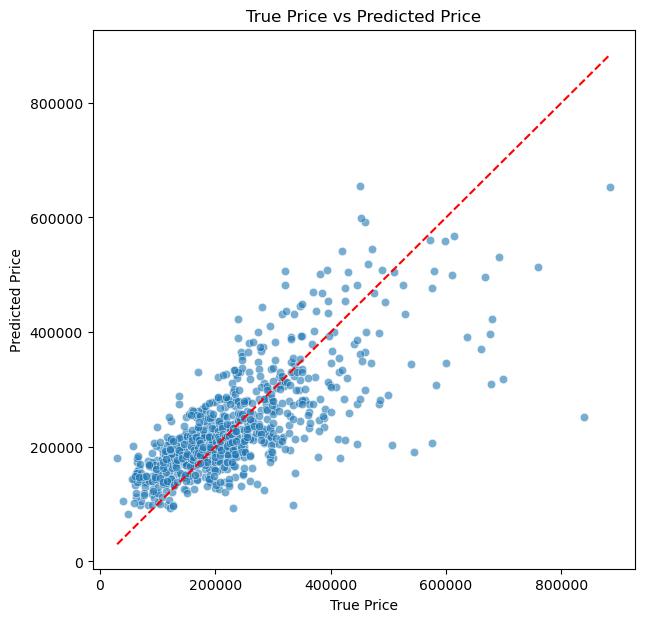

In [51]:
housing['y_pred'] = model.predict(X)
plt.figure(figsize=(7, 7))
sns.scatterplot(data=housing, x='price', y='y_pred', alpha=0.6)

min_val = min(housing['price'].min(), housing['y_pred'].min())
max_val = max(housing['price'].max(), housing['y_pred'].max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")

plt.title("True Price vs Predicted Price")
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.show()
y_pred_test = model.predict(X_test)

### 13. List the five assumptions for an MLR model. 

Indicate which ones are the same as the assumptions for an SLR model. 

**The Five Assumptions of the MLR Model (and Which Ones Are Shared with SLR):**

1. **Linearity** - The relationship between the independent variables and the dependent variable is linear. *(Shared with SLR)*
2. **Independence of errors** - The residuals are independent of each other (no serial correlation). *(Shared with SLR)*
3. **Homoscedasticity** - The variance of residuals is constant across all levels of the independent variables. *(Shared with SLR)*
4. **Normality of residuals** - The residuals roughly follow a normal distribution. *(Shared with SLR)*
5. **No/low Multicollinearity** - This assumption is **specific to MLR only** (it doesn’t make sense in SLR because there’s only one independent variable).

### 14. Pick at least two assumptions and explain whether or not you believe them to be met for your model, and explain why.

**Evaluating Two Assumptions of Our Model:**

- **Homoscedasticity:** From the residuals vs. `sqft` plot in question 8, it seems like the spread of residuals increases with larger square footage (fan-shaped). This suggests that the assumption is **not fully met** – errors are bigger for larger, more expensive houses.

- **Low Multicollinearity:** The variables `sqft`, `beds`, and `baths` are moderately to strongly correlated (correlation around 0.66-0.72 between each pair) since they all reflect home size. This means that this assumption is **also not fully met**, which is one reason the model improved when `beds` was later removed in the iteration (Q18).

### 15. Regression Metrics

Implement a function called `r2_adj()` that will calculate $R^2_{adj}$ for a model.

The adjusted R-squared is calculated as $R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - k - 1} \right]$.

Unlike standard R-squared, which always increases when you add new variables, Adjusted R-squared will actually decrease if you add a useless variable to your model. This helps you find the simplest and most effective model.
- $R^2$: The standard R-squared value (coefficient of determination)
- $n$: The total number of observations (sample size)
- $k$: The number of independent variables (predictors) in your model

In [60]:
def r2_adj(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

# quick check using our test set
r2_test = r2_score(y_test, y_pred_test)
n_test = X_test.shape[0]
k_test = X_test.shape[1]


print(f"R2:            {r2_test:.4f}")
print(f"R2 Adjusted:   {r2_adj(r2_test, n_test, k_test):.4f}")

R2:            0.5496
R2 Adjusted:   0.5352


### 17. Metrics, metrics, everywhere...

Calculate and interpret at least three regression metrics. How well does your model perform?

In [56]:

r2_val = r2_score(y_test, y_pred)
rmse_val = mean_squared_error(y_test, y_pred) ** 0.5
mae_val = mean_absolute_error(y_test, y_pred)

print(f"R2:            {r2_val:.4f}")
print(f"R2 Adjusted:   {adj_r2_val:.4f}")
print(f"RMSE:          {rmse_val:,.2f}")
print(f"MAE:           {mae_val:,.2f}")

R2:            0.5496
R2 Adjusted:   0.5352
RMSE:          74,345.33
MAE:           54,671.55


### 18. Model Iteration

Adjust your model by adding or removing a variable. Then calculate the same regression metrics as you used in question 17. Has your model performance increased or decreased?

**Guidance:**
1. Look at the correlation between the dependent and independent variables. Which two predictors are the most correlated with each other?
2. Drop the one you think is less useful and refit the model with the remaining features.
3. Compare the new R2 and RMSE to your original model from Q11/Q17.


In [43]:
print(housing_dummies[['sq__ft', 'beds', 'baths']].corr())

features_v2 = ['sq__ft', 'baths'] + list(type_dummies.columns)
X_v2 = housing_dummies[features_v2]

X_v2_train, X_v2_test, y_v2_train, y_v2_test = train_test_split(X_v2, y, test_size=0.2, random_state=42)
model_v2 = LinearRegression().fit(X_v2_train, y_v2_train)
pred_v2 = model_v2.predict(X_v2_test)

r2_v2 = r2_score(y_v2_test, pred_v2)
rmse_v2 = mean_squared_error(y_v2_test, pred_v2) ** 0.5

print(f"\n The original model -> R2: {r2_val:.4f} | RMSE: {rmse_val:,.2f}")
print(f"Without the form beds -> R2: {r2_v2:.4f} | RMSE: {rmse_v2:,.2f}")

          sq__ft      beds     baths
sq__ft  1.000000  0.716979  0.722341
beds    0.716979  1.000000  0.657982
baths   0.722341  0.657982  1.000000

 The original model -> R2: 0.5496 | RMSE: 74,345.33
Without the form beds -> R2: 0.5553 | RMSE: 73,878.58


### 19. Add `city` as a feature

Use `OneHotEncoder` on the `city` column to add location as a feature. Since some cities only have 1-2 sales, group cities with fewer than 20 sales into `'Other'` first. Compare R2 and RMSE to the base model.

In [44]:
city_counts = housing_dummies['city'].value_counts()
rare_cities = city_counts[city_counts < 20].index

housing_dummies['city_grouped'] = housing_dummies['city'].where(
    ~housing_dummies['city'].isin(rare_cities), 'Other'
)
print(housing_dummies['city_grouped'].value_counts())

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
city_encoded = ohe.fit_transform(housing_dummies[['city_grouped']])
city_cols = ohe.get_feature_names_out(['city_grouped'])
city_df = pd.DataFrame(city_encoded, columns=city_cols, index=housing_dummies.index)

housing_dummies = pd.concat([housing_dummies, city_df], axis=1)

features_v3 = features_v2 + list(city_cols)
X_v3 = housing_dummies[features_v3]

X_v3_train, X_v3_test, y_v3_train, y_v3_test = train_test_split(X_v3, y, test_size=0.2, random_state=42)
model_v3 = LinearRegression().fit(X_v3_train, y_v3_train)
pred_v3 = model_v3.predict(X_v3_test)

r2_v3 = r2_score(y_v3_test, pred_v3)
rmse_v3 = mean_squared_error(y_v3_test, pred_v3) ** 0.5


city_grouped
SACRAMENTO         422
ELK GROVE          107
Other              104
CITRUS HEIGHTS      34
ANTELOPE            33
ROSEVILLE           28
RANCHO CORDOVA      21
NORTH HIGHLANDS     21
GALT                20
CARMICHAEL          20
Name: count, dtype: int64


## Part 2: Sacramento Real Estate Deep Dive & Model Diagnostics

---

### 21. Beating the Baseline
A machine learning model is only useful if it performs better than a "naive guess". Create a baseline model:

Calculate the mean `price` of your training data to get the "Baseline" prediction, then, report how much money "on average" does your MLR model save us in pricing errors compared to just guessing using the average?

In [45]:
baseline_prediction = np.full_like(y_v3_test, y_v3_train.mean(), dtype=float)

rmse_baseline = mean_squared_error(y_v3_test, baseline_prediction) ** 0.5
rmse_model = rmse_v3

savings = rmse_baseline - rmse_model

print(f"Baseline (Average price) RMSE:  {rmse_baseline:,.2f}")
print(f"Model MLR RMSE:               {rmse_model:,.2f}")
print(f"Average savings on pricing error: {savings:,.2f} A dollar for each property")

Baseline (Average price) RMSE:  111,101.79
Model MLR RMSE:               69,304.45
Average savings on pricing error: 41,797.34 A dollar for each property


### 22. Which Feature Matters Most?
To explain our model accurately, we use **Feature Scaling** to force all features to be on a similar scale, allowing us to compare their "weight" equally.

Fit a new Linear Regression model on this **scaled** training data and find the new coefficients. Based on these scaled coefficients, which feature does the model actually rely on the most to determine a house's price?

In [46]:
scaler = StandardScaler()
X_v3_train_scaled = scaler.fit_transform(X_v3_train)
X_v3_test_scaled = scaler.transform(X_v3_test)

model_scaled = LinearRegression().fit(X_v3_train_scaled, y_v3_train)

scaled_coefs = pd.Series(model_scaled.coef_, index=features_v3).sort_values(key=abs, ascending=False)
print(scaled_coefs)

print(f"\n The factor that affects the price the most( After unification/scaling) is: {scaled_coefs.index[0]}")

sq__ft                          77794.038849
city_grouped_Other              31393.850432
city_grouped_CARMICHAEL         12665.954699
city_grouped_ROSEVILLE          11861.070935
type_Residential                 4926.279681
baths                            4703.468172
type_Multi-Family               -4225.524176
city_grouped_NORTH HIGHLANDS    -3731.889370
city_grouped_ELK GROVE           2875.063329
city_grouped_CITRUS HEIGHTS      2244.991599
city_grouped_SACRAMENTO         -1667.583451
city_grouped_GALT                1096.157369
city_grouped_RANCHO CORDOVA      -665.402443
dtype: float64

 The factor that affects the price the most( After unification/scaling) is: sq__ft


### 23. Does the model generalize to the real world?
A model that perfectly memorizes the training data but fails completely on new unseen houses is useless. We call a model's ability to succeed on new data **Generalization**.

Using your scaled MLR model from Question 22:

* **Step 1:** Predict prices for the **training** set and calculate the training RMSE.

* **Step 2:** Predict prices for the **testing** set and calculate the testing RMSE.

Is the model performing significantly worse on the test data? What does this tell you about how the model generalizes?

In [47]:
train_pred_scaled = model_scaled.predict(X_v3_train_scaled)
test_pred_scaled = model_scaled.predict(X_v3_test_scaled)

train_rmse = mean_squared_error(y_v3_train, train_pred_scaled) ** 0.5
test_rmse = mean_squared_error(y_v3_test, test_pred_scaled) ** 0.5
train_r2 = r2_score(y_v3_train, train_pred_scaled)
test_r2 = r2_score(y_v3_test, test_pred_scaled)

print(f"Train -> R2: {train_r2:.4f} | RMSE: {train_rmse:,.2f}")
print(f"Test  -> R2: {test_r2:.4f}  | RMSE: {test_rmse:,.2f}")

Train -> R2: 0.6102 | RMSE: 75,964.44
Test  -> R2: 0.6086  | RMSE: 69,304.45


### 24. The Bias-Variance Tradeoff

In machine learning, there is a constant battle between Bias and Variance:
* **High Bias (Underfitting):** The model is very simple. It performs poorly on the training data as well as on the testing data.
* **High Variance (Overfitting):** The model is very complex. It memorizes the training data (high R-squared) but performs terribly on unseen testing data.
* **The Sweet Spot:** The model performs well on both the training set and the test set, with very little drop-off in performance.

Looking back at the Train and Test metrics you calculated for your Multiple Linear Regression model, is your model suffering from High Bias, High Variance, or is it in the sweet spot? Explain your reasoning.

Looking at the results above:
- The difference between R2 on training (0.61) and R2 on testing (0.61) is very small, almost negligible.
- The difference between training and testing RMSE is also limited.

If the model had **High Bias**, its performance would be poor on both training and testing (low R2 in both). If it had **High Variance**, we would see a big gap between training performance (very high) and testing performance (much lower). Since the performance is close and reasonable (though not perfect) on both sets, the model is relatively simple (Linear Regression without extra complexity), which explains the lack of obvious overfitting. But the average R2 (~0.61) means there's still room to improve the model's explanatory power (maybe by adding new variables or addressing non-linearity).

### 25. Force High Variance to compare the outcomes
Let's see what the Bias-Variance Tradeoff looks like when we break the model on purpose! 

If we use `OneHotEncoder` on the `city` column **without** grouping the rare cities into "Other", we will a lot of new columns. Many of these columns will only have 1 or 2 houses in them. Explain the gap between the Train R-squared and Test R-squared.

In [48]:
ohe_full = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
city_full_encoded = ohe_full.fit_transform(housing_dummies[['city']])
city_full_cols = ohe_full.get_feature_names_out(['city'])
city_full_df = pd.DataFrame(city_full_encoded, columns=city_full_cols, index=housing_dummies.index)

housing_full_city = pd.concat([housing_dummies, city_full_df], axis=1)

features_v4 = features_v2 + list(city_full_cols)
X_v4 = housing_full_city[features_v4]

X_v4_train, X_v4_test, y_v4_train, y_v4_test = train_test_split(X_v4, y, test_size=0.2, random_state=42)
model_v4 = LinearRegression().fit(X_v4_train, y_v4_train)

train_r2_v4 = r2_score(y_v4_train, model_v4.predict(X_v4_train))
test_r2_v4 = r2_score(y_v4_test, model_v4.predict(X_v4_test))

print(f"Number of city columns without grouping: {len(city_full_cols)}")
print(f"Train R2: {train_r2_v4:.4f}")
print(f"Test  R2: {test_r2_v4:.4f}")
print(f"The gap (Train - Test): {train_r2_v4 - test_r2_v4:.4f}")

Number of city columns without grouping: 34
Train R2: 0.6734
Test  R2: 0.6249
The gap (Train - Test): 0.0485


### 26. Interpreting & Explaining Results to Non-Technical Audiences
Data science is useless if the business doesn't understand your results. Avoid using technical jargon. How would you translate your model's performance for the executives?

**How do we explain the results to a non-technical audience?**

- Our model can explain about **61%** of the differences in home prices in Sacramento, based on the home's size, number of bathrooms, type, and the city/neighborhood it's in.
- On average, the model's price estimates are off by **around $69,000** from the actual price. This is clearly better than just guessing the average price of all homes (which is off by 111,000 on average), meaning the model **gives us about 42,000 more accuracy per property** compared to a simple guess.
- The most important factor affecting the price is **home size**, followed by **location (city)**.
- We need to be careful when applying the model to cities that barely appear in our data (like cities with only one or two deals) because the model might give unreliable estimates for them – as we saw when we tried 'breaking' the model without grouping rare cities.